Dataset root: /kaggle/input/nasa-cmaps
Files in root:
['CMaps', 'cmaps']
Found train_FD002.txt at:
/kaggle/input/nasa-cmaps/CMaps/train_FD002.txt
   0   1        2       3      4       5       6        7        8     9   \
0   1   1  34.9983  0.8400  100.0  449.44  555.32  1358.61  1137.23  5.48   
1   1   2  41.9982  0.8408  100.0  445.00  549.90  1353.22  1125.78  3.91   
2   1   3  24.9988  0.6218   60.0  462.54  537.31  1256.76  1047.45  7.05   
3   1   4  42.0077  0.8416  100.0  445.00  549.51  1354.03  1126.38  3.91   
4   1   5  25.0005  0.6203   60.0  462.54  537.07  1257.71  1047.93  7.05   

   ...      16       17       18       19    20   21    22      23     24  \
0  ...  183.06  2387.72  8048.56   9.3461  0.02  334  2223  100.00  14.73   
1  ...  130.42  2387.66  8072.30   9.3774  0.02  330  2212  100.00  10.41   
2  ...  164.22  2028.03  7864.87  10.8941  0.02  309  1915   84.93  14.08   
3  ...  130.72  2387.61  8068.66   9.3528  0.02  329  2212  100.00  10.59   
4  ...

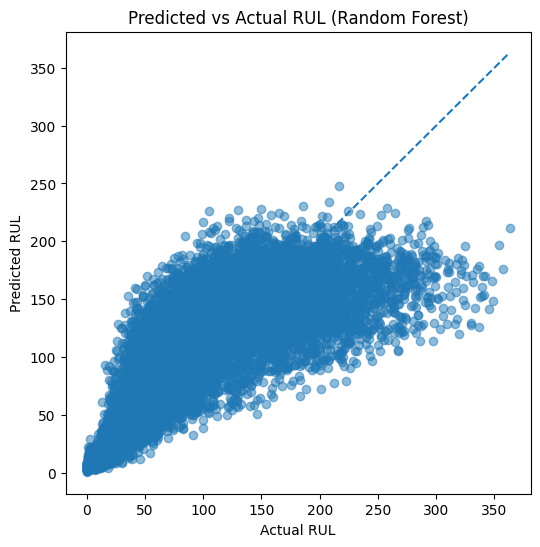

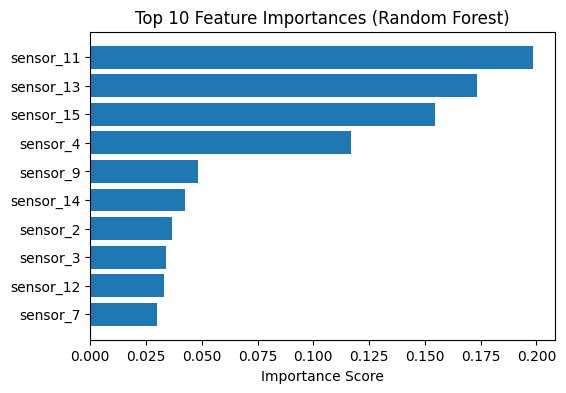

sensor_11    0.198486
sensor_13    0.173471
sensor_15    0.154338
sensor_4     0.116932
sensor_9     0.048231
sensor_14    0.042340
sensor_2     0.036787
sensor_3     0.034000
sensor_12    0.032860
sensor_7     0.029971
dtype: float64

In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np
import pandas as pd

dataset_path = kagglehub.dataset_download("behrad3d/nasa-cmaps")

print("Dataset root:", dataset_path)
print("Files in root:")
print(os.listdir(dataset_path))

train_fd002_path = None

for root, dirs, files in os.walk(dataset_path):
    if "train_FD002.txt" in files:
        train_fd002_path = os.path.join(root, "train_FD002.txt")
        break

print("Found train_FD002.txt at:")
print(train_fd002_path)


df = pd.read_csv(
    train_fd002_path,
    sep=r'\s+',   # chuẩn pandas mới
    header=None
)

print(df.head())
print("Shape:", df.shape)
column_names = (
    ['engine_id', 'cycle'] +
    [f'op_setting_{i}' for i in range(1, 4)] +
    [f'sensor_{i}' for i in range(1, 22)]
)

df.columns = column_names

df.head()


#RUL Calculation
# Calculate max cycle for each engine
max_cycle = df.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id', 'max_cycle']

# Merge to original dataframe
df = df.merge(max_cycle, on='engine_id')

# Compute RUL
df['RUL'] = df['max_cycle'] - df['cycle']

# Drop helper column
df.drop(columns=['max_cycle'], inplace=True)

df[['engine_id', 'cycle', 'RUL']].head()
#Feature Selection
# Input features (exclude engine_id, cycle, and target)
X = df.drop(columns=['engine_id', 'cycle', 'RUL'])

# Target variable
y = df['RUL']

print("Input shape:", X.shape)
print("Target shape:", y.shape)

#Feature Scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

#Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

#Model design and training
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

#Lineaer 
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

#Random forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

#SVR
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X_train, y_train)


#Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate_regression(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return mae, rmse, r2
results = {
    "Linear Regression": evaluate_regression(lr_model, X_test, y_test),
    "Random Forest": evaluate_regression(rf_model, X_test, y_test),
    "SVR": evaluate_regression(svr_model, X_test, y_test)
}

results_df = pd.DataFrame(
    results,
    index=["MAE", "RMSE", "R2"]
).T

print("\nModel Comparison Results:")
print(results_df)
# ===============================
# Naive Baseline Model (Mean RUL)
# ===============================
y_pred_mean = np.full_like(y_test, y_train.mean())

baseline_mae = mean_absolute_error(y_test, y_pred_mean)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_mean))
baseline_r2 = r2_score(y_test, y_pred_mean)

print("\nBaseline (Mean RUL) Performance:")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R2  :", baseline_r2)



#Visualization
import matplotlib.pyplot as plt
y_pred_rf = rf_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs Actual RUL (Random Forest)")
plt.show()

importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(6, 4))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.xlabel("Importance Score")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()


# Display top 10 most important features
top_features = pd.Series(importances, index=X.columns) \
                .sort_values(ascending=False) \
                .head(10)

top_features